In [17]:
from google.colab import drive
drive.mount('/content/drive')

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.metrics import roc_curve, auc

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
# Loading Evaluation metrics data for the Adult Income Dataset
knn_adult_metrics = pd.read_csv('/content/drive/MyDrive/MLDS_GroupNotebook_ResultsPlot/knn_adult_metrics.csv')
mlp_adult_metrics = pd.read_csv('/content/drive/MyDrive/MLDS_GroupNotebook_ResultsPlot/mlp_results_adult.csv')
dt_adult_metrics = pd.read_csv('/content/drive/MyDrive/MLDS_GroupNotebook_ResultsPlot/dt_adult_metrics.csv')
svm_adult_metrics = pd.read_csv('/content/drive/MyDrive/MLDS_GroupNotebook_ResultsPlot/svm_results_adult.csv')

In [29]:
# Dataframe is created differently, so using 'dict' and 'zip' to help enable easier access to the metrics' values
mlp_ad_metrics = dict(zip(mlp_adult_metrics['Metric'], mlp_adult_metrics['Value']))

dt_adult_metricsbest = dt_adult_metrics[dt_adult_metrics['Model'] == 'Threshold-Optimised DT (t=0.45)']

# Algorithms' metrics comparison on adult income dataset
metrics_all_adults = pd.DataFrame({
    'Metrics': ['Accuracy','Balanced Accuracy', 'Weighted F1', 'Macro F1'],
    'kNN': [knn_adult_metrics['Accuracy'].values[0],
            knn_adult_metrics['Balanced Accuracy'].values[0],
            knn_adult_metrics['Weighted-F1'].values[0],
            knn_adult_metrics['Macro-F1'].values[0]],
    'MLP': [mlp_ad_metrics['Accuracy'],
            mlp_ad_metrics['balanced_acc'],
            mlp_ad_metrics['weighted_f1'],
            mlp_ad_metrics['macrof1_score']],
    'SVM': [svm_adult_metrics['adult_accuracy'].values[0],
            svm_adult_metrics['adult_balanced_accuracy'].values[0],
            svm_adult_metrics['adult_weighted_f1'].values[0],
            svm_adult_metrics['adult_macro_f1'].values[0]],
    'Decision Tree': [dt_adult_metricsbest['Accuracy'].values[0],
                      dt_adult_metricsbest['Balanced Accuracy'].values[0],
                      dt_adult_metricsbest['Weighted F1'].values[0],
                      dt_adult_metricsbest['Macro F1'].values[0]]
})

metrics_all_adults

,Metrics,kNN,MLP,Decision Tree,SVM
0,Accuracy,0.842666,0.814515,0.8656,0.829665
1,Balanced Accuracy,0.765693,0.709960,0.7950,0.841866
2,Weighted F1,0.839537,0.806770,0.8626,0.838719
3,Macro F1,0.769991,0.724931,0.8073,0.794123


In [34]:
# Loading Evaluation metrics data for the IBM-HR Dataset
knn_ibm_metrics = pd.read_csv('/content/drive/MyDrive/MLDS_GroupNotebook_ResultsPlot/knn_ibm_metrics.csv')
mlp_ibm_metrics = pd.read_csv('/content/drive/MyDrive/MLDS_GroupNotebook_ResultsPlot/mlp_results_ibm.csv')
dt_ibm_metrics = pd.read_csv('/content/drive/MyDrive/MLDS_GroupNotebook_ResultsPlot/dt_ibm_metrics.csv')
svm_ibm_metrics = pd.read_csv('/content/drive/MyDrive/MLDS_GroupNotebook_ResultsPlot/svm_results_ibm.csv')

# Dataframe is oriented differently, so using 'dict' and 'zip' to help enable easier access to the metrics' values
mlp_ibm_metricsrev = dict(zip(mlp_ibm_metrics['Metric'], mlp_ibm_metrics['Value']))

# Algorithms' metrics comparison on adult income dataset
metrics_all_ibm = pd.DataFrame({
    'Metrics': ['Accuracy','Balanced Accuracy', 'Weighted F1', 'Macro F1'],
    'kNN': [knn_ibm_metrics['Accuracy'].values[0],
            knn_ibm_metrics['Balanced Accuracy'].values[0],
            knn_ibm_metrics['Weighted-F1'].values[0],
            knn_ibm_metrics['Macro-F1'].values[0]],
    'MLP': [mlp_ibm_metricsrev['Accuracy'],
            mlp_ibm_metricsrev['balanced_acc'],
            mlp_ibm_metricsrev['weighted_f1'],
            mlp_ibm_metricsrev['macrof1_score']],
    'SVM': [svm_ibm_metrics['ibm_accuracy'].values[0],
            svm_ibm_metrics['ibm_balanced_accuracy'].values[0],
            svm_ibm_metrics['ibm_weighted_f1'].values[0],
            svm_ibm_metrics['ibm_macro_f1'].values[0]],
     'Decision Tree': [dt_ibm_metrics['Accuracy'].values[0],
                      dt_ibm_metrics['Balanced Accuracy'].values[0],
                      dt_ibm_metrics['Weighted F1'].values[0],
                      dt_ibm_metrics['Macro F1'].values[0]]
})

metrics_all_ibm

,Metrics,kNN,MLP,Decision Tree,SVM
0,Accuracy,0.843537,0.853741,0.7891,0.867347
1,Balanced Accuracy,0.588164,0.680377,0.7194,0.697088
2,Weighted F1,0.814545,0.845643,0.8061,0.858403
3,Macro F1,0.586998,0.698390,0.6754,0.720798


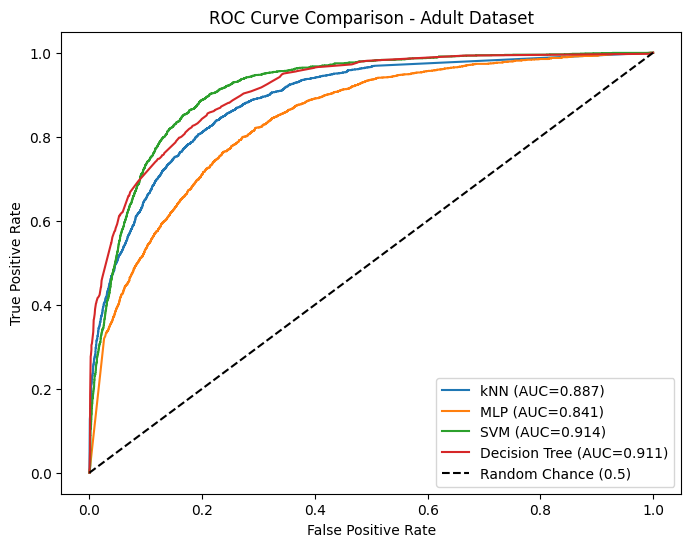

In [35]:
# Loading ROC curve data for the Adult Income Dataset - COMPUTE AUC
knn_roc_adult = pd.read_csv('/content/drive/MyDrive/MLDS_GroupNotebook_ResultsPlot/knn_roc_adult.csv')
mlp_roc_adult = pd.read_csv('/content/drive/MyDrive/MLDS_GroupNotebook_ResultsPlot/mlp_roc_values_adult.csv')
dt_roc_adult = pd.read_csv('/content/drive/MyDrive/MLDS_GroupNotebook_ResultsPlot/dt_roc_adult.csv')
svm_roc_adult = pd.read_csv('/content/drive/MyDrive/MLDS_GroupNotebook_ResultsPlot/svm_adult_roc.csv')

knn_fpr, knn_tpr, _ = roc_curve(knn_roc_adult['y_true'], knn_roc_adult['y_score'])
mlp_fpr, mlp_tpr = mlp_roc_adult['FPR'], mlp_roc_adult['TPR']
dt_fpr, dt_tpr = dt_roc_adult['False Positive Rate'], dt_roc_adult['True Positive Rate']
svm_fpr, svm_tpr = svm_roc_adult['adult_fpr'], svm_roc_adult['adult_tpr']

# Computing Area Under ROC curves
knn_auc = auc(knn_fpr, knn_tpr)
mlp_auc = auc(mlp_fpr, mlp_tpr)
svm_auc = auc(svm_fpr, svm_tpr)
dt_auc = auc(dt_fpr, dt_tpr)

plt.figure(figsize=(8,6))
plt.plot(knn_fpr, knn_tpr, label=f'kNN (AUC={knn_auc:.3f})')
plt.plot(mlp_fpr, mlp_tpr, label=f'MLP (AUC={mlp_auc:.3f})')
plt.plot(svm_fpr, svm_tpr, label=f'SVM (AUC={svm_auc:.3f})')
plt.plot(dt_fpr, dt_tpr, label=f'Decision Tree (AUC={dt_auc:.3f})')

plt.plot([0,1], [0,1], 'k--', label = 'Random Chance (0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison - Adult Dataset')
plt.legend()

plt.show()

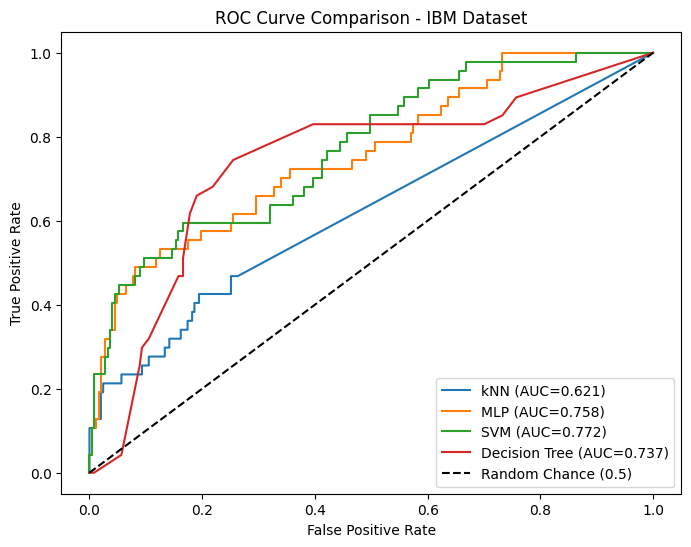

In [37]:
# Loading ROC curve data for the IBM-HR Dataset - COMPUTE AUC
knn_roc_ibm = pd.read_csv('/content/drive/MyDrive/MLDS_GroupNotebook_ResultsPlot/knn_roc_ibm.csv')
mlp_roc_ibm = pd.read_csv('/content/drive/MyDrive/MLDS_GroupNotebook_ResultsPlot/mlp_roc_values_IBM.csv')
dt_roc_ibm = pd.read_csv('/content/drive/MyDrive/MLDS_GroupNotebook_ResultsPlot/dt_roc_ibm.csv')
svm_roc_ibm = pd.read_csv('/content/drive/MyDrive/MLDS_GroupNotebook_ResultsPlot/svm_ibm_roc.csv')

knn_fpr, knn_tpr, _ = roc_curve(knn_roc_ibm['y_true'],knn_roc_ibm['y_score'])
mlp_fpr, mlp_tpr = mlp_roc_ibm['FPR'], mlp_roc_ibm['TPR']
svm_fpr, svm_tpr = svm_roc_ibm['ibm_fpr'], svm_roc_ibm['ibm_tpr']
dt_fpr, dt_tpr = dt_roc_ibm['False Positive Rate'], dt_roc_ibm['True Positive Rate']

# Computing Area Under ROC curves
knn_auc = auc(knn_fpr, knn_tpr)
mlp_auc = auc(mlp_fpr, mlp_tpr)
svm_auc = auc(svm_fpr, svm_tpr)
dt_auc = auc(dt_fpr, dt_tpr)

plt.figure(figsize=(8,6))
plt.plot(knn_fpr, knn_tpr, label=f'kNN (AUC={knn_auc:.3f})')
plt.plot(mlp_fpr, mlp_tpr, label=f'MLP (AUC={mlp_auc:.3f})')
plt.plot(svm_fpr, svm_tpr, label=f'SVM (AUC={svm_auc:.3f})')
plt.plot(dt_fpr, dt_tpr, label=f'Decision Tree (AUC={dt_auc:.3f})')

plt.plot([0,1], [0,1], 'k--', label = 'Random Chance (0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison - IBM Dataset')
plt.legend()

plt.show()